# KV Cache Benchmark Visualization

This notebook loads `benchmark_results.csv` and generates charts comparing paged KV cache, non-paged KV cache, and no KV cache generation.

In [17]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

try:
    from benchmarking.config import BENCHMARK_RESULTS_CSV_PATH
except ModuleNotFoundError:
    from config import BENCHMARK_RESULTS_CSV_PATH

plt.style.use('ggplot')

CSV_PATH = Path(BENCHMARK_RESULTS_CSV_PATH)
if not CSV_PATH.exists():
    raise FileNotFoundError(f'Could not find {CSV_PATH.resolve()}')

df = pd.read_csv(CSV_PATH)
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], errors='coerce')
df['execution_device'] = df['execution_device'].astype(str)
df['mode'] = df['mode'].astype(str)

numeric_cols = [
    'prompt_tokens', 'new_tokens', 'total_tokens_processed', 'avg_seconds',
    'tokens_per_second', 'speedup_vs_no_cache', 'block_size', 'total_blocks'
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Rows:', len(df))
print('Modes:', sorted(df['mode'].dropna().unique().tolist()))
print('Devices:', sorted(df['execution_device'].dropna().unique().tolist()))
display(df.head(5))

Rows: 170
Modes: ['kv_cache', 'kv_cache_no_paging', 'no_kv_cache']
Devices: ['cpu']


,timestamp_utc,benchmark_label,execution_device,cuda_available,mode,prompt,prompt_tokens,new_tokens,total_tokens_processed,total_blocks,...,warmup_runs,timed_runs,avg_seconds,stdev_seconds,min_seconds,max_seconds,median_seconds,tokens_per_second,speedup_vs_no_cache,run_durations_json
0,2026-04-12 05:06:07.421679+00:00,kv_cache_vs_no_kv_cache,cpu,False,kv_cache,Hi,1,50,51,128,...,1,1,0.803780,0.0,0.803780,0.803780,0.803780,62.206084,1.523134,[0.8037799000740051]
1,2026-04-12 05:06:07.421679+00:00,kv_cache_vs_no_kv_cache,cpu,False,no_kv_cache,Hi,1,50,51,128,...,1,1,1.224265,0.0,1.224265,1.224265,1.224265,40.840841,1.000000,[1.2242646999657154]
2,2026-04-12 05:06:17.195082+00:00,kv_cache_vs_no_kv_cache,cpu,False,kv_cache,Hi there,2,75,77,128,...,1,1,1.235915,0.0,1.235915,1.235915,1.235915,60.683805,3.363865,[1.2359146000817418]
3,2026-04-12 05:06:17.195082+00:00,kv_cache_vs_no_kv_cache,cpu,False,no_kv_cache,Hi there,2,75,77,128,...,1,1,4.157450,0.0,4.157450,4.157450,4.157450,18.039906,1.000000,[4.1574495998211205]
4,2026-04-12 05:06:35.233923+00:00,kv_cache_vs_no_kv_cache,cpu,False,kv_cache,The quick brown fox,4,100,104,128,...,1,1,2.301700,0.0,2.301700,2.301700,2.301700,43.446139,2.729962,[2.3017004998400807]


In [18]:
# Build aligned trial table (one row per timestamp/prompt/new_tokens config)
pair_keys = ['timestamp_utc', 'prompt', 'new_tokens', 'prompt_tokens', 'execution_device']

kv_paged = (
    df[df['mode'] == 'kv_cache'][pair_keys + ['avg_seconds', 'tokens_per_second', 'speedup_vs_no_cache', 'block_size', 'total_blocks']]
    .rename(columns={
        'avg_seconds': 'paged_avg_seconds',
        'tokens_per_second': 'paged_tokens_per_second',
        'speedup_vs_no_cache': 'paged_reported_speedup',
        'block_size': 'paged_block_size',
        'total_blocks': 'paged_total_blocks',
    })
)

kv_no_paging = (
    df[df['mode'] == 'kv_cache_no_paging'][pair_keys + ['avg_seconds', 'tokens_per_second', 'speedup_vs_no_cache', 'block_size', 'total_blocks']]
    .rename(columns={
        'avg_seconds': 'no_paging_avg_seconds',
        'tokens_per_second': 'no_paging_tokens_per_second',
        'speedup_vs_no_cache': 'no_paging_reported_speedup',
        'block_size': 'no_paging_block_size',
        'total_blocks': 'no_paging_total_blocks',
    })
)

no_kv = (
    df[df['mode'] == 'no_kv_cache'][pair_keys + ['avg_seconds', 'tokens_per_second']]
    .rename(columns={
        'avg_seconds': 'no_kv_avg_seconds',
        'tokens_per_second': 'no_kv_tokens_per_second',
    })
)

# Keep historical 2-way trials by pairing paged KV with no-KV first, then attach no-paging when available.
paired = kv_paged.merge(no_kv, on=pair_keys, how='inner').merge(kv_no_paging, on=pair_keys, how='left')
paired['paged_computed_speedup'] = paired['no_kv_avg_seconds'] / paired['paged_avg_seconds']
paired['no_paging_computed_speedup'] = paired['no_kv_avg_seconds'] / paired['no_paging_avg_seconds']
paired = paired.sort_values(['new_tokens', 'prompt_tokens']).reset_index(drop=True)

print('Paired baseline trials:', len(paired))
print('Trials with no-paging data:', int(paired['no_paging_avg_seconds'].notna().sum()))
display(paired.head(10))

Paired baseline trials: 68
Trials with no-paging data: 34


,timestamp_utc,prompt,new_tokens,prompt_tokens,execution_device,paged_avg_seconds,paged_tokens_per_second,paged_reported_speedup,paged_block_size,paged_total_blocks,no_kv_avg_seconds,no_kv_tokens_per_second,no_paging_avg_seconds,no_paging_tokens_per_second,no_paging_reported_speedup,no_paging_block_size,no_paging_total_blocks,paged_computed_speedup,no_paging_computed_speedup
0,2026-04-13 16:59:16.974572+00:00,Refactor test,30,3,cpu,1.848384,16.230390,1.677939,16,128,3.101477,9.672810,NaN,NaN,NaN,NaN,NaN,1.677939,NaN
1,2026-04-13 17:01:05.017926+00:00,Final verification,40,2,cpu,2.857246,13.999493,1.566017,16,32,4.474496,8.939554,NaN,NaN,NaN,NaN,NaN,1.566017,NaN
2,2026-04-15 00:38:16.537972+00:00,Final verification,40,2,cpu,2.798635,14.292682,1.467098,16,32,4.105871,9.742148,2.601013,15.378623,1.578566,44.0,1.0,1.467098,1.578566
3,2026-04-12 05:06:07.421679+00:00,Hi,50,1,cpu,0.803780,62.206084,1.523134,16,128,1.224265,40.840841,NaN,NaN,NaN,NaN,NaN,1.523134,NaN
4,2026-04-12 05:13:43.146918+00:00,AI,50,1,cpu,1.990429,25.120218,1.809280,16,128,3.601243,13.884096,NaN,NaN,NaN,NaN,NaN,1.809280,NaN
5,2026-04-15 00:08:32.889147+00:00,Hi,50,1,cpu,1.254874,39.844647,1.112140,16,128,1.395595,35.827021,1.182104,42.297452,1.180602,53.0,1.0,1.112140,1.180602
6,2026-04-15 00:49:09.850415+00:00,Hi,50,1,cpu,1.001770,49.911651,1.314287,53,1,1.316614,37.976205,0.993182,50.343225,1.325652,53.0,1.0,1.314287,1.325652
7,2026-04-13 17:00:25.595045+00:00,Checking refactor,50,4,cpu,3.644716,13.718489,1.631173,8,128,5.945164,8.410198,NaN,NaN,NaN,NaN,NaN,1.631173,NaN
8,2026-04-15 00:37:25.813890+00:00,Checking refactor,50,4,cpu,3.504182,14.268667,1.768799,8,128,6.198192,8.066869,3.311884,15.097148,1.871500,56.0,1.0,1.768799,1.871500
9,2026-04-12 05:17:29.455393+00:00,One two three,60,3,cpu,2.938324,20.419802,1.904870,4,128,5.597125,10.719790,NaN,NaN,NaN,NaN,NaN,1.904870,NaN


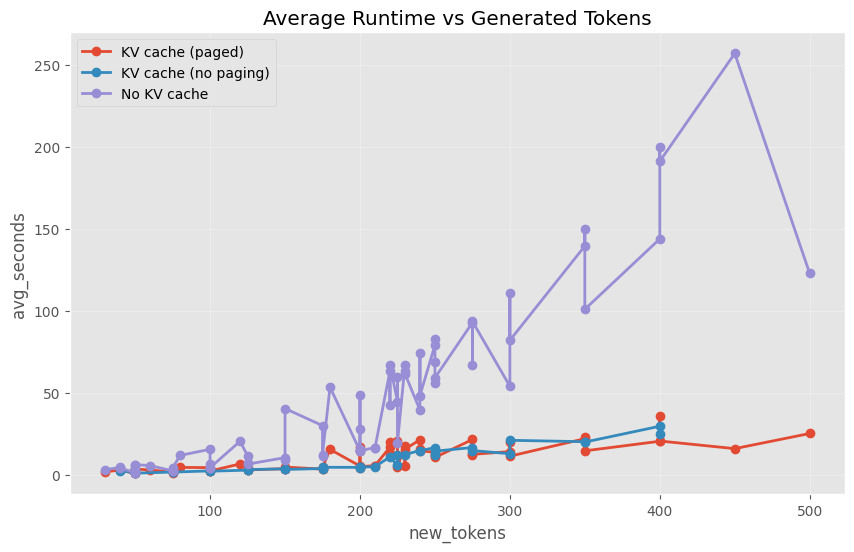

In [19]:
# Chart 1: runtime vs generated tokens (all modes)
fig, ax = plt.subplots(figsize=(10, 6))
for mode, label in [
    ('kv_cache', 'KV cache (paged)'),
    ('kv_cache_no_paging', 'KV cache (no paging)'),
    ('no_kv_cache', 'No KV cache'),
]:
    view = df[df['mode'] == mode].sort_values('new_tokens')
    ax.plot(view['new_tokens'], view['avg_seconds'], marker='o', linewidth=2, label=label)

ax.set_title('Average Runtime vs Generated Tokens')
ax.set_xlabel('new_tokens')
ax.set_ylabel('avg_seconds')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

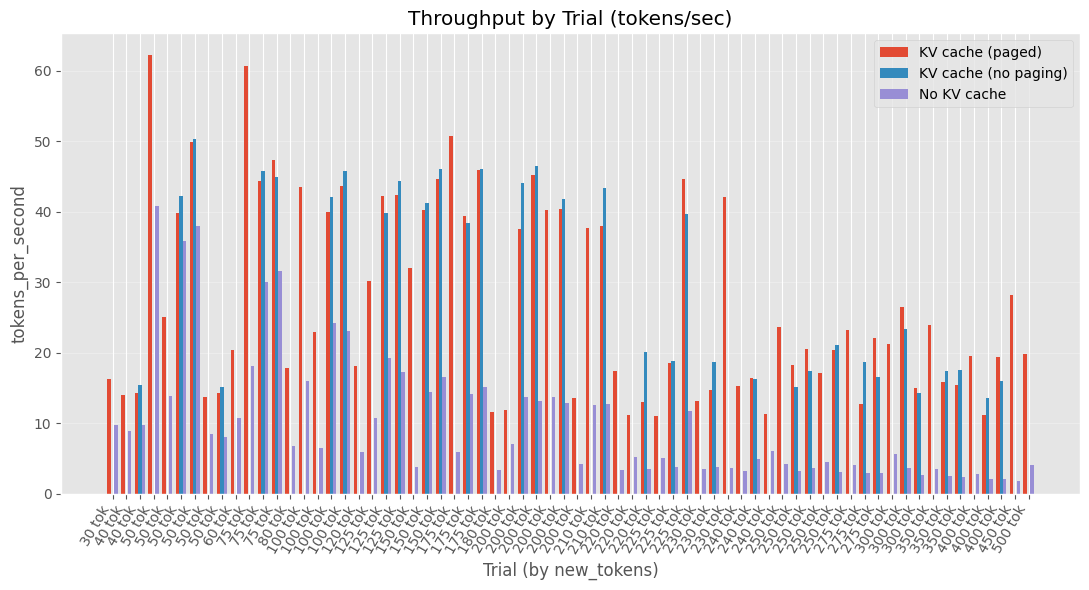

In [20]:
# Chart 2: throughput comparison (tokens/sec)
fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(paired))
width = 0.25

ax.bar([i - width for i in x], paired['paged_tokens_per_second'], width=width, label='KV cache (paged)')
ax.bar([i for i in x], paired['no_paging_tokens_per_second'], width=width, label='KV cache (no paging)')
ax.bar([i + width for i in x], paired['no_kv_tokens_per_second'], width=width, label='No KV cache')

labels = [f"{int(n)} tok" for n in paired['new_tokens']]
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=60, ha='right')
ax.set_title('Throughput by Trial (tokens/sec)')
ax.set_xlabel('Trial (by new_tokens)')
ax.set_ylabel('tokens_per_second')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

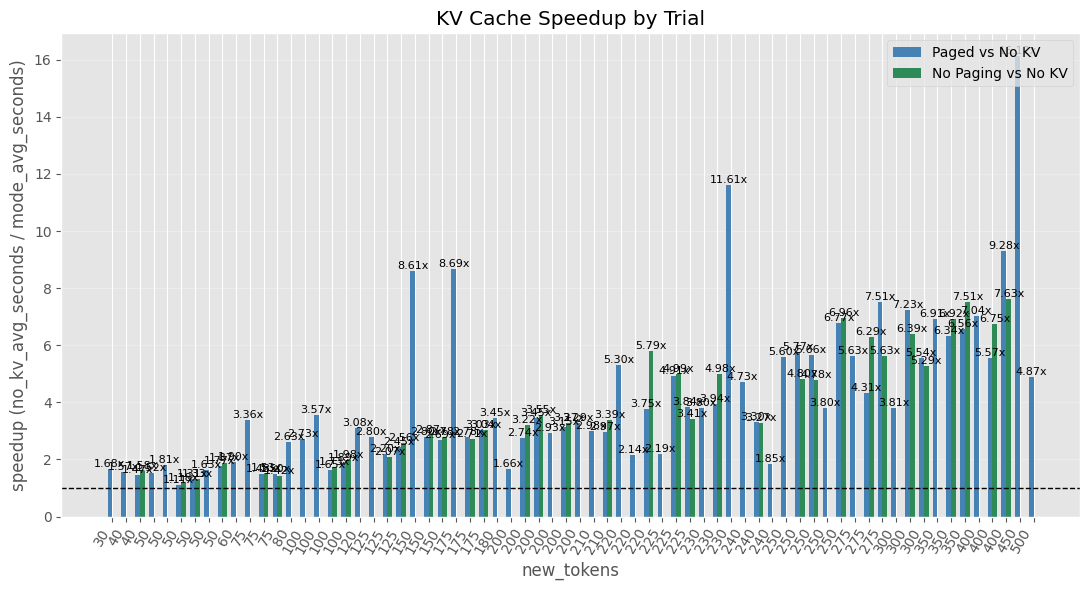

{'trials': 68,
 'device': 'cpu',
 'paged_avg_speedup_x': 4.05899251116387,
 'paged_median_speedup_x': 3.29638967987048,
 'no_paging_avg_speedup_x': 3.9254621776459855,
 'no_paging_median_speedup_x': 3.3316794110680386,
 'no_paging_trials': 34}

In [21]:
# Chart 3: speedup and summary
fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(paired))
width = 0.35

paged_bars = ax.bar(
    [i - width / 2 for i in x],
    paired['paged_computed_speedup'],
    width=width,
    color='steelblue',
    label='Paged vs No KV',
)
no_paging_bars = ax.bar(
    [i + width / 2 for i in x],
    paired['no_paging_computed_speedup'],
    width=width,
    color='seagreen',
    label='No Paging vs No KV',
)

ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_xticks(range(len(paired)))
ax.set_xticklabels([f"{int(n)}" for n in paired['new_tokens']], rotation=60, ha='right')
ax.set_title('KV Cache Speedup by Trial')
ax.set_xlabel('new_tokens')
ax.set_ylabel('speedup (no_kv_avg_seconds / mode_avg_seconds)')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

for bars in (paged_bars, no_paging_bars):
    for i, b in enumerate(bars):
        values = paired['paged_computed_speedup'] if bars is paged_bars else paired['no_paging_computed_speedup']
        value = values.iloc[i]
        if pd.notna(value):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{value:.2f}x", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

summary = {
    'trials': int(len(paired)),
    'device': paired['execution_device'].mode().iloc[0] if len(paired) else 'unknown',
    'paged_avg_speedup_x': float(paired['paged_computed_speedup'].mean()) if len(paired) else float('nan'),
    'paged_median_speedup_x': float(paired['paged_computed_speedup'].median()) if len(paired) else float('nan'),
    'no_paging_avg_speedup_x': float(paired['no_paging_computed_speedup'].mean(skipna=True)) if len(paired) else float('nan'),
    'no_paging_median_speedup_x': float(paired['no_paging_computed_speedup'].median(skipna=True)) if len(paired) else float('nan'),
    'no_paging_trials': int(paired['no_paging_avg_seconds'].notna().sum()) if len(paired) else 0,
}
summary